In [2]:
import pymc as pm
import arviz as az
import numpy as np

occurrences = [1, 1, 1, 1, 1, 1, 1, 0, 0, 0]

print(f"Observed data: {occurrences}")
print(f"Number of successes: {sum(occurrences)}")
print(f"Total patients: {len(occurrences)}")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


Observed data: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0]
Number of successes: 7
Total patients: 10


In [3]:
with pm.Model() as model:
    p = pm.Uniform('p', lower=0, upper=1)
    
    obs = pm.Bernoulli("obs", p, observed=occurrences)
    
    idata = pm.sample(2000, tune=2500, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


c:\Users\jasin\AppData\Local\Programs\Python\Python313\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 18 seconds.


## Obserwacje dla 10 pacjentów:

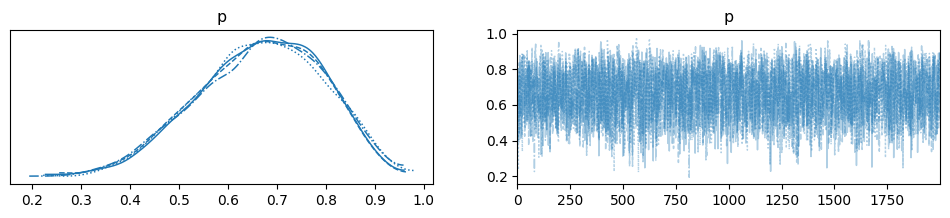

array([[<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>]],
      dtype=object)

In [4]:
az.plot_trace(idata, show=True)

## Obserwacje dla 100 pacjentów:

Obserwacje dla 100 pacjentów:


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


c:\Users\jasin\AppData\Local\Programs\Python\Python313\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 24 seconds.


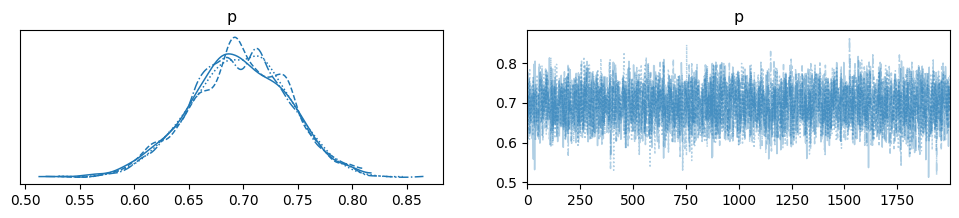

array([[<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>]],
      dtype=object)

In [6]:
ones = np.ones(70)
zeros = np.zeros(30)
simulated_data = np.concatenate([ones, zeros])
print("Obserwacje dla 100 pacjentów:")

with pm.Model() as model:
    p = pm.Uniform('p', lower=0, upper=1)
    
    obs = pm.Bernoulli("obs", p, observed=simulated_data)
    
    idata = pm.sample(2000, tune=2500, random_seed=42)

az.plot_trace(idata, show=True)

## Obserwacje dla 1000 pacjentów:

Initializing NUTS using jitter+adapt_diag...


Obserwacje dla 1000 pacjentów:


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


c:\Users\jasin\AppData\Local\Programs\Python\Python313\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 71 seconds.


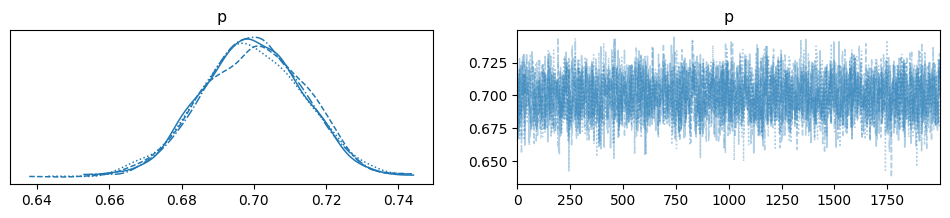

array([[<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>]],
      dtype=object)

In [7]:
ones = np.ones(700)
zeros = np.zeros(300)
simulated_data = np.concatenate([ones, zeros])
print("Obserwacje dla 1000 pacjentów:")

with pm.Model() as model:
    p = pm.Uniform('p', lower=0, upper=1)
    
    obs = pm.Bernoulli("obs", p, observed=simulated_data)
    
    idata = pm.sample(2000, tune=2500, random_seed=42)

az.plot_trace(idata, show=True)

### Wnioski:

Im większa grupa pacjentów, tym rozkład Bernoulliego staje się "węższy" i pewniejszy prawdopodobieństwu działania leku.
Przy 10 próbkach rozkład przyjmuje prawdopodobne wartości od zakresu 0.3 do 0.9, podczas gdy dla 1000 próbek - już tylko od 0.65 do 0.72 .